## ADVERSARIAL ATTACKS ON FEDERATED LEARNING MODELS: A COMPARATIVE ANALYSIS

In [1]:
import copy
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset
from aijack.collaborative.fedavg import FedAVGAPI, FedAVGClient, FedAVGServer
from aijack.attack.inversion import GradientInversionAttackServerManager

#### baseline set up

Using: 1 client, 1 round of communication, batch_size=1, MNIST dataset

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
input_shape = (1, 28, 28) # MNIST shape
num_classes = 10

In [3]:
#BASELINE MODEL: LeNet with Sigmoid activations
class LeNet(nn.Module):
    def __init__(self):
        super(LeNet, self).__init__()
        act = nn.Sigmoid 
        self.body = nn.Sequential(
            nn.Conv2d(1, 12, kernel_size=5, padding=2, stride=2),
            act(),
            nn.Conv2d(12, 12, kernel_size=5, padding=2, stride=2),
            act(),
        )
        self.fc = nn.Sequential(nn.Linear(12 * 7 * 7, num_classes))

    def forward(self, x):
        out = self.body(x)
        out = out.view(out.size(0), -1)
        return self.fc(out)


transform = transforms.Compose([transforms.ToTensor()])
dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)

secret_x_cpu, secret_y_raw = dataset[7]
secret_x_cpu = secret_x_cpu.unsqueeze(0)  
secret_y_cpu = torch.tensor([secret_y_raw], dtype=torch.long)
secret_x = secret_x_cpu.to(device)

In [4]:
# Gradient Inversion Attack Server Manager
manager = GradientInversionAttackServerManager(
    input_shape,
    device=device,
    num_iteration=100,
    lr=1.0,
    log_interval=20,
    optimizer_class=torch.optim.LBFGS,
    distancename="l2"
 )
AttackingServer = manager.attach(FedAVGServer)

In [5]:
#FL environment baseline setup for the attack
base_model = LeNet().to(device)
client = FedAVGClient(copy.deepcopy(base_model), user_id=0, lr=0.1, device=device)
server = AttackingServer([client], copy.deepcopy(base_model), device=device)
criterion = nn.CrossEntropyLoss()
local_dataloaders = [DataLoader(TensorDataset(secret_x_cpu, secret_y_cpu), batch_size=1, shuffle=False)]
local_optimizers = [optim.SGD(client.parameters(), lr=client.lr)]

api = FedAVGAPI(
    server,
    [client],
    criterion,
    local_optimizers,
    local_dataloaders,
    num_communication=1,
    local_epoch=1,
    use_gradients=True,
    device=device,
 )

print("Starting Reconstruction Attack...")
api.run()
reconstructed_data, reconstructed_label = server.attack_results[0][0]

Starting Reconstruction Attack...
iter=20: 8.210922608498095e-09, (best_iter=8: 8.210922608498095e-09)
iter=40: 8.210922608498095e-09, (best_iter=8: 8.210922608498095e-09)
iter=59: loss did not improve in the last 50 rounds.


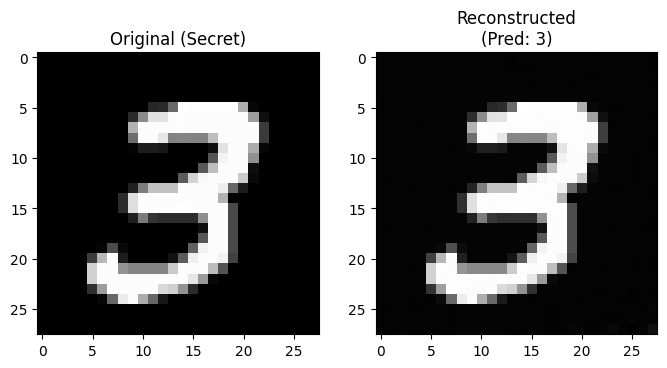

In [6]:
#Visualize the original and reconstructed images
plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.title("Original (Secret)")
plt.imshow(secret_x_cpu[0][0].detach().numpy(), cmap='gray')

plt.subplot(1, 2, 2)
if reconstructed_label.ndim == 0:
    pred_label = int(reconstructed_label.item())
elif reconstructed_label.ndim == 1:
    pred_label = int(torch.argmax(reconstructed_label).item())
else:
    pred_label = int(torch.argmax(reconstructed_label[0]).item())
plt.title(f"Reconstructed\n(Pred: {pred_label})")
plt.imshow(reconstructed_data[0][0].cpu().detach().numpy(), cmap='gray')
plt.show()

Experiment #1: using more than 1 communication round 

Running attack at idx 7, round 1, seed 0 ...
iter=20: 5.441537442862909e-09, (best_iter=9: 5.441537442862909e-09)
iter=40: 5.441537442862909e-09, (best_iter=9: 5.441537442862909e-09)
iter=60: 5.441537442862909e-09, (best_iter=9: 5.441537442862909e-09)
iter=60: loss did not improve in the last 50 rounds.
Running attack at idx 7, round 1, seed 1 ...
iter=20: 5.500668809332865e-09, (best_iter=6: 5.500668809332865e-09)
iter=40: 5.500668809332865e-09, (best_iter=6: 5.500668809332865e-09)
iter=57: loss did not improve in the last 50 rounds.
Running attack at idx 7, round 1, seed 2 ...
iter=20: 6.907621585838797e-09, (best_iter=7: 6.907621585838797e-09)
iter=40: 6.907621585838797e-09, (best_iter=7: 6.907621585838797e-09)
iter=58: loss did not improve in the last 50 rounds.
Running attack at idx 7, round 1, seed 3 ...
iter=20: 7.260697820754558e-09, (best_iter=5: 7.260697820754558e-09)
iter=40: 7.260697820754558e-09, (best_iter=5: 7.260697820754558e-09)
iter=56: loss did not improve in the las

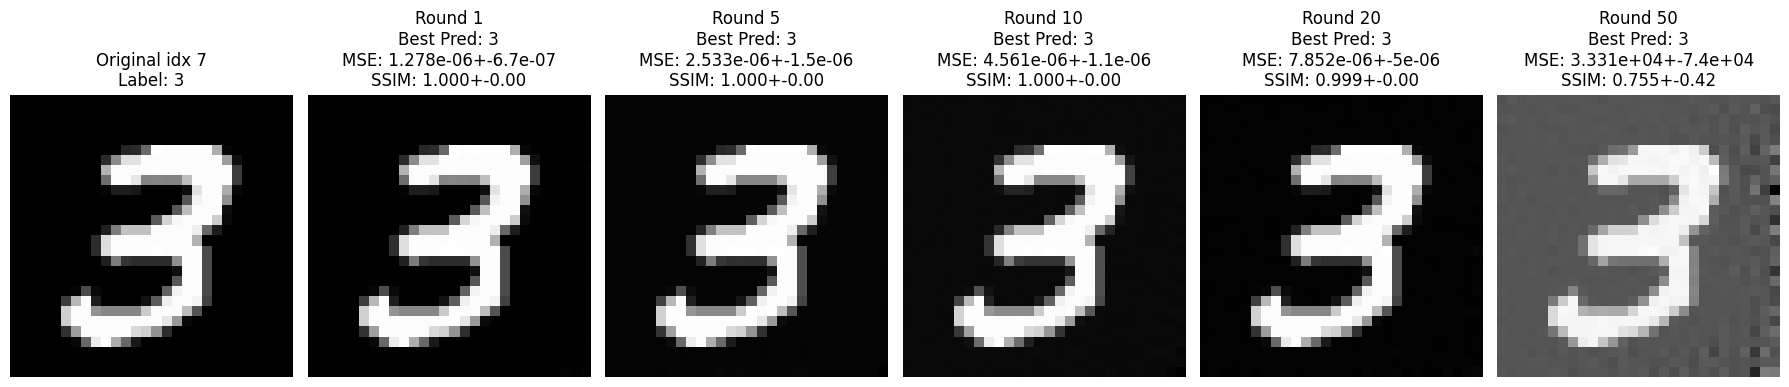


Global summary by round (all secrets + all seeds):
Round   1 | MSE 0.000001 +- 0.000001 | SSIM 0.9999 +- 0.0000 | Label Acc 100.0%
Round   5 | MSE 37554.370838 +- 145447.452814 | SSIM 0.9325 +- 0.2580 | Label Acc 100.0%
Round  10 | MSE 0.000006 +- 0.000004 | SSIM 0.9997 +- 0.0002 | Label Acc 100.0%
Round  20 | MSE 271373073.066674 +- 1051023392.596326 | SSIM 0.9328 +- 0.2581 | Label Acc 100.0%
Round  50 | MSE 13576.221888 +- 43386.923022 | SSIM 0.7790 +- 0.3323 | Label Acc 93.3%

Robust summary by round (median [p25, p75]):
Round   1 | MSE 0.000001 [0.000000, 0.000002] | SSIM 0.9999 [0.9999, 1.0000] | Label Acc 100.0%
Round   5 | MSE 0.000002 [0.000001, 0.000005] | SSIM 0.9998 [0.9992, 1.0000] | Label Acc 100.0%
Round  10 | MSE 0.000005 [0.000004, 0.000007] | SSIM 0.9997 [0.9995, 0.9999] | Label Acc 100.0%
Round  20 | MSE 0.000006 [0.000004, 0.000014] | SSIM 0.9995 [0.9990, 0.9999] | Label Acc 100.0%
Round  50 | MSE 0.004226 [0.001276, 0.020323] | SSIM 0.9270 [0.7832, 0.9773] | Label 

In [18]:
# EXPERIMENT: ATTACK VS COMMUNICATION ROUND 
from torch.utils.data import Subset, TensorDataset
from skimage.metrics import structural_similarity as ssim
import pandas as pd
import numpy as np
import os

#Goal: compare reconstruction quality across rounds with multiple seeds and multiple secret samples.

target_rounds = [1, 5, 10, 20, 50]
seeds = [0, 1, 2, 3, 4]
secret_indices = [7, 13, 25]
viz_secret_index = secret_indices[0]

pretrain_subset_size = 1024
pretrain_batch_size = 64
client_lr = 0.1

subset_indices = list(range(min(pretrain_subset_size, len(dataset))))
pretrain_subset = Subset(dataset, subset_indices)

def make_pretrain_loader(seed: int):
    g = torch.Generator()
    g.manual_seed(seed)
    return DataLoader(
        pretrain_subset,
        batch_size=pretrain_batch_size,
        shuffle=True,
        generator=g,
    )

def run_attack_at_round(target_round: int, seed: int, secret_index: int):
    torch.manual_seed(seed)
    np.random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    pretrain_loader = make_pretrain_loader(seed)

    
    secret_x_cpu, secret_y_raw = dataset[secret_index]
    secret_x_cpu = secret_x_cpu.unsqueeze(0)
    secret_y_cpu = torch.tensor([secret_y_raw], dtype=torch.long)

    
    base_model_tmp = LeNet().to(device)
    client_tmp = FedAVGClient(copy.deepcopy(base_model_tmp), user_id=0, lr=client_lr, device=device)

    if target_round > 1:
        standard_server_tmp = FedAVGServer([client_tmp], copy.deepcopy(base_model_tmp), device=device)
        api_pretrain_tmp = FedAVGAPI(
            standard_server_tmp,
            [client_tmp],
            criterion,
            [optim.SGD(client_tmp.parameters(), lr=client_lr)],
            [pretrain_loader],
            num_communication=target_round - 1,
            local_epoch=1,
            use_gradients=False,
            device=device,
        )
        api_pretrain_tmp.run()
        attack_init_model = copy.deepcopy(standard_server_tmp.server_model)
    else:
        attack_init_model = copy.deepcopy(base_model_tmp)


    local_dataloaders_tmp = [DataLoader(TensorDataset(secret_x_cpu, secret_y_cpu), batch_size=1, shuffle=False)]
    attacking_server_tmp = AttackingServer([client_tmp], attack_init_model, device=device)
    api_attack_tmp = FedAVGAPI(
        attacking_server_tmp,
        [client_tmp],
        criterion,
        [optim.SGD(client_tmp.parameters(), lr=client_lr)],
        local_dataloaders_tmp,
        num_communication=1,
        local_epoch=1,
        use_gradients=True,
        device=device,
    )
    api_attack_tmp.run()

    recon_x, recon_y = attacking_server_tmp.attack_results[-1][0]

    if recon_y.ndim == 0:
        pred_label = int(recon_y.item())
    elif recon_y.ndim == 1:
        pred_label = int(torch.argmax(recon_y).item())
    else:
        pred_label = int(torch.argmax(recon_y[0]).item())

    recon_img = recon_x[0][0].detach().cpu().numpy()
    secret_img = secret_x_cpu[0][0].detach().cpu().numpy()

    mse = float(np.mean((recon_img - secret_img) ** 2))
    ssim_score = float(ssim(secret_img, recon_img, data_range=1.0))
    label_ok = int(pred_label == int(secret_y_cpu.item()))

    return {
        "round": target_round,
        "seed": seed,
        "secret_index": secret_index,
        "pred_label": pred_label,
        "true_label": int(secret_y_cpu.item()),
        "label_ok": label_ok,
        "mse": mse,
        "ssim": ssim_score,
        "recon_x": recon_x,
        "secret_x_cpu": secret_x_cpu,
    }


raw_results = []
for idx in secret_indices:
    for r in target_rounds:
        for s in seeds:
            print(f"Running attack at idx {idx}, round {r}, seed {s} ...")
            raw_results.append(run_attack_at_round(r, s, idx))

#TABLES
raw_rows = [
    {
        "secret_index": x["secret_index"],
        "round": x["round"],
        "seed": x["seed"],
        "true_label": x["true_label"],
        "pred_label": x["pred_label"],
        "label_ok": x["label_ok"],
        "mse": x["mse"],
        "ssim": x["ssim"],
    }
    for x in raw_results
]
df_raw = pd.DataFrame(raw_rows)

# Mean/std summaries
df_summary = df_raw.groupby("round", as_index=False).agg(
    mse_mean=("mse", "mean"),
    mse_std=("mse", "std"),
    ssim_mean=("ssim", "mean"),
    ssim_std=("ssim", "std"),
    label_acc=("label_ok", "mean"),
)
df_summary["label_acc"] = 100.0 * df_summary["label_acc"]

df_summary_by_secret = df_raw.groupby(["secret_index", "round"], as_index=False).agg(
    mse_mean=("mse", "mean"),
    mse_std=("mse", "std"),
    ssim_mean=("ssim", "mean"),
    ssim_std=("ssim", "std"),
    label_acc=("label_ok", "mean"),
)
df_summary_by_secret["label_acc"] = 100.0 * df_summary_by_secret["label_acc"]

# Robust summaries (median + quartiles + IQR)
robust_rows = []
for r, grp in df_raw.groupby("round"):
    mse_q25 = float(grp["mse"].quantile(0.25))
    mse_q75 = float(grp["mse"].quantile(0.75))
    ssim_q25 = float(grp["ssim"].quantile(0.25))
    ssim_q75 = float(grp["ssim"].quantile(0.75))
    robust_rows.append({
        "round": int(r),
        "mse_median": float(grp["mse"].median()),
        "mse_q25": mse_q25,
        "mse_q75": mse_q75,
        "mse_iqr": mse_q75 - mse_q25,
        "ssim_median": float(grp["ssim"].median()),
        "ssim_q25": ssim_q25,
        "ssim_q75": ssim_q75,
        "ssim_iqr": ssim_q75 - ssim_q25,
        "label_acc": 100.0 * float(grp["label_ok"].mean()),
    })
df_summary_robust = pd.DataFrame(robust_rows).sort_values("round").reset_index(drop=True)

robust_by_secret_rows = []
for (idx, r), grp in df_raw.groupby(["secret_index", "round"]):
    mse_q25 = float(grp["mse"].quantile(0.25))
    mse_q75 = float(grp["mse"].quantile(0.75))
    ssim_q25 = float(grp["ssim"].quantile(0.25))
    ssim_q75 = float(grp["ssim"].quantile(0.75))
    robust_by_secret_rows.append({
        "secret_index": int(idx),
        "round": int(r),
        "mse_median": float(grp["mse"].median()),
        "mse_q25": mse_q25,
        "mse_q75": mse_q75,
        "mse_iqr": mse_q75 - mse_q25,
        "ssim_median": float(grp["ssim"].median()),
        "ssim_q25": ssim_q25,
        "ssim_q75": ssim_q75,
        "ssim_iqr": ssim_q75 - ssim_q25,
        "label_acc": 100.0 * float(grp["label_ok"].mean()),
    })
df_summary_robust_by_secret = pd.DataFrame(robust_by_secret_rows).sort_values(["secret_index", "round"]).reset_index(drop=True)

#SAVE CSV OUTPUTS
os.makedirs("results/baseline", exist_ok=True)
raw_csv_path = "results/baseline/attack_vs_round_multisecret_raw.csv"
summary_csv_path = "results/baseline/attack_vs_round_multisecret_summary.csv"
summary_by_secret_csv_path = "results/baseline/attack_vs_round_multisecret_summary_by_secret.csv"
summary_robust_csv_path = "results/baseline/attack_vs_round_multisecret_summary_robust.csv"
summary_robust_by_secret_csv_path = "results/baseline/attack_vs_round_multisecret_summary_robust_by_secret.csv"
df_raw.to_csv(raw_csv_path, index=False)
df_summary.to_csv(summary_csv_path, index=False)
df_summary_by_secret.to_csv(summary_by_secret_csv_path, index=False)
df_summary_robust.to_csv(summary_robust_csv_path, index=False)
df_summary_robust_by_secret.to_csv(summary_robust_by_secret_csv_path, index=False)


viz_candidates = [x for x in raw_results if x["secret_index"] == viz_secret_index]
if len(viz_candidates) > 0:
    best_by_round = {}
    for r in target_rounds:
        candidates = [x for x in viz_candidates if x["round"] == r]
        best_by_round[r] = min(candidates, key=lambda x: x["mse"])

    secret_ref = viz_candidates[0]["secret_x_cpu"]
    true_ref_label = int(viz_candidates[0]["true_label"])

    n_cols = len(target_rounds) + 1
    plt.figure(figsize=(3 * n_cols, 3.8))

    plt.subplot(1, n_cols, 1)
    plt.title(f"Original idx {viz_secret_index}\nLabel: {true_ref_label}")
    plt.imshow(secret_ref[0][0].detach().numpy(), cmap="gray")
    plt.axis("off")

    for i, r in enumerate(target_rounds, start=2):
        best = best_by_round[r]
        srow = df_summary_by_secret[
            (df_summary_by_secret["secret_index"] == viz_secret_index) &
            (df_summary_by_secret["round"] == r)
        ].iloc[0]
        plt.subplot(1, n_cols, i)
        plt.title(
            f"Round {r}\n"
            f"Best Pred: {best['pred_label']}\n"
            f"MSE: {srow['mse_mean']:.4g}+-{srow['mse_std']:.2g}\n"
            f"SSIM: {srow['ssim_mean']:.3f}+-{srow['ssim_std']:.2f}"
        )
        plt.imshow(best["recon_x"][0][0].detach().cpu().numpy(), cmap="gray")
        plt.axis("off")

    plt.tight_layout()
    plt.show()


print("\nGlobal summary by round (all secrets + all seeds):")
for _, row in df_summary.sort_values("round").iterrows():
    print(
        f"Round {int(row['round']):>3} | "
        f"MSE {row['mse_mean']:.6f} +- {row['mse_std']:.6f} | "
        f"SSIM {row['ssim_mean']:.4f} +- {row['ssim_std']:.4f} | "
        f"Label Acc {row['label_acc']:.1f}%"
    )

print("\nRobust summary by round (median [p25, p75]):")
for _, row in df_summary_robust.sort_values("round").iterrows():
    print(
        f"Round {int(row['round']):>3} | "
        f"MSE {row['mse_median']:.6f} [{row['mse_q25']:.6f}, {row['mse_q75']:.6f}] | "
        f"SSIM {row['ssim_median']:.4f} [{row['ssim_q25']:.4f}, {row['ssim_q75']:.4f}] | "
        f"Label Acc {row['label_acc']:.1f}%"
    )

print("\nSaved raw results: " + raw_csv_path)
print("Saved global summary: " + summary_csv_path)
print("Saved by-secret summary: " + summary_by_secret_csv_path)
print("Saved robust summary: " + summary_robust_csv_path)
print("Saved robust by-secret summary: " + summary_robust_by_secret_csv_path)

In [19]:
import pandas as pd
import os

raw_csv_path = "results/baseline/attack_vs_round_multisecret_raw.csv"
summary_robust_csv_path = "results/baseline/attack_vs_round_multisecret_summary_robust.csv"
summary_robust_by_secret_csv_path = "results/baseline/attack_vs_round_multisecret_summary_robust_by_secret.csv"

if not os.path.exists(raw_csv_path):
    raise FileNotFoundError(f"Raw CSV not found: {raw_csv_path}")

df_raw = pd.read_csv(raw_csv_path)

robust_rows = []
for r, grp in df_raw.groupby("round"):
    mse_q25 = float(grp["mse"].quantile(0.25))
    mse_q75 = float(grp["mse"].quantile(0.75))
    ssim_q25 = float(grp["ssim"].quantile(0.25))
    ssim_q75 = float(grp["ssim"].quantile(0.75))
    robust_rows.append({
        "round": int(r),
        "mse_median": float(grp["mse"].median()),
        "mse_q25": mse_q25,
        "mse_q75": mse_q75,
        "mse_iqr": mse_q75 - mse_q25,
        "ssim_median": float(grp["ssim"].median()),
        "ssim_q25": ssim_q25,
        "ssim_q75": ssim_q75,
        "ssim_iqr": ssim_q75 - ssim_q25,
        "label_acc": 100.0 * float(grp["label_ok"].mean()),
    })
df_summary_robust = pd.DataFrame(robust_rows).sort_values("round").reset_index(drop=True)

robust_by_secret_rows = []
for (idx, r), grp in df_raw.groupby(["secret_index", "round"]):
    mse_q25 = float(grp["mse"].quantile(0.25))
    mse_q75 = float(grp["mse"].quantile(0.75))
    ssim_q25 = float(grp["ssim"].quantile(0.25))
    ssim_q75 = float(grp["ssim"].quantile(0.75))
    robust_by_secret_rows.append({
        "secret_index": int(idx),
        "round": int(r),
        "mse_median": float(grp["mse"].median()),
        "mse_q25": mse_q25,
        "mse_q75": mse_q75,
        "mse_iqr": mse_q75 - mse_q25,
        "ssim_median": float(grp["ssim"].median()),
        "ssim_q25": ssim_q25,
        "ssim_q75": ssim_q75,
        "ssim_iqr": ssim_q75 - ssim_q25,
        "label_acc": 100.0 * float(grp["label_ok"].mean()),
    })
df_summary_robust_by_secret = pd.DataFrame(robust_by_secret_rows).sort_values(["secret_index", "round"]).reset_index(drop=True)

df_summary_robust.to_csv(summary_robust_csv_path, index=False)
df_summary_robust_by_secret.to_csv(summary_robust_by_secret_csv_path, index=False)

print("Robust summary by round (median [p25, p75]):")
for _, row in df_summary_robust.iterrows():
    print(
        f"Round {int(row['round']):>3} | "
        f"MSE {row['mse_median']:.6f} [{row['mse_q25']:.6f}, {row['mse_q75']:.6f}] | "
        f"SSIM {row['ssim_median']:.4f} [{row['ssim_q25']:.4f}, {row['ssim_q75']:.4f}] | "
        f"Label Acc {row['label_acc']:.1f}%"
    )

print("\nSaved robust summary: " + summary_robust_csv_path)
print("Saved robust by-secret summary: " + summary_robust_by_secret_csv_path)

Robust summary by round (median [p25, p75]):
Round   1 | MSE 0.000001 [0.000000, 0.000002] | SSIM 0.9999 [0.9999, 1.0000] | Label Acc 100.0%
Round   5 | MSE 0.000002 [0.000001, 0.000005] | SSIM 0.9998 [0.9992, 1.0000] | Label Acc 100.0%
Round  10 | MSE 0.000005 [0.000004, 0.000007] | SSIM 0.9997 [0.9995, 0.9999] | Label Acc 100.0%
Round  20 | MSE 0.000006 [0.000004, 0.000014] | SSIM 0.9995 [0.9990, 0.9999] | Label Acc 100.0%
Round  50 | MSE 0.004226 [0.001276, 0.020323] | SSIM 0.9270 [0.7832, 0.9773] | Label Acc 93.3%

Saved robust summary: results/baseline/attack_vs_round_multisecret_summary_robust.csv
Saved robust by-secret summary: results/baseline/attack_vs_round_multisecret_summary_robust_by_secret.csv


Experiment #2: batch size >1

In [ ]:
#EXPERIMENT: BATCH SIZE IMPACT (ROUND 1, MULTI-SEED, MULTI-SECRET)

from skimage.metrics import structural_similarity as ssim
import pandas as pd
import numpy as np
import os



# Keep communication round fixed at 1.

target_round = 1
batch_sizes = [1, 4, 8, 16, 32]
secret_indices_bs = [7, 13, 25]
seeds_bs = [0, 1, 2]
client_lr_bs = 0.1



AttackingServer = manager.attach(FedAVGServer)
def build_batch_with_secret(dataset, secret_index, batch_size, seed):
    rng = np.random.default_rng(seed + 1000 * secret_index + 10000 * batch_size)
    if batch_size == 1:
        batch_indices = [secret_index]
    else:
        batch_indices = [secret_index]
        while len(batch_indices) < batch_size:
            idx = int(rng.integers(0, len(dataset)))
            if idx != secret_index and idx not in batch_indices:
                batch_indices.append(idx)
        rng.shuffle(batch_indices)

    secret_pos = batch_indices.index(secret_index)
    x_list, y_list = [], []
    for idx in batch_indices:
        x_i, y_i = dataset[idx]
        x_list.append(x_i)
        y_list.append(y_i)



    batch_x_cpu = torch.stack(x_list, dim=0)
    batch_y_cpu = torch.tensor(y_list, dtype=torch.long)
    return batch_x_cpu, batch_y_cpu, secret_pos



def run_attack_batchsize(batch_size, seed, secret_index):
    torch.manual_seed(seed)
    np.random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    batch_x_cpu, batch_y_cpu, secret_pos = build_batch_with_secret(dataset, secret_index, batch_size, seed)
    secret_x_cpu = batch_x_cpu[secret_pos:secret_pos + 1]
    true_label = int(batch_y_cpu[secret_pos].item())

    base_model_tmp = LeNet().to(device)

    client_tmp = FedAVGClient(copy.deepcopy(base_model_tmp), user_id=0, lr=client_lr_bs, device=device)

    server_tmp = AttackingServer([client_tmp], copy.deepcopy(base_model_tmp), device=device)

    local_dataloaders_tmp = [

        DataLoader(TensorDataset(batch_x_cpu, batch_y_cpu), batch_size=batch_size, shuffle=False)]

    local_optimizers_tmp = [optim.SGD(client_tmp.parameters(), lr=client_lr_bs)]

    api_tmp = FedAVGAPI(
        server_tmp,
        [client_tmp],
        criterion,
        local_optimizers_tmp,
        local_dataloaders_tmp,
        num_communication=target_round,
        local_epoch=1,
        use_gradients=True,
        device=device,
)

    api_tmp.run()



    recon_x, recon_y = server_tmp.attack_results[-1][0]
    recon_x_cpu = recon_x.detach().cpu()



    

    secret_img = secret_x_cpu[0, 0].detach().cpu().numpy()

    if recon_x_cpu.ndim == 4:
        mse_candidates = [
            float(np.mean((recon_x_cpu[i, 0].numpy() - secret_img) ** 2))
            for i in range(recon_x_cpu.shape[0])

        ]

        best_idx = int(np.argmin(mse_candidates))
        recon_img = recon_x_cpu[best_idx, 0].numpy()
        mse_score = mse_candidates[best_idx]

    else:

        recon_img = recon_x_cpu[0, 0].numpy()
        mse_score = float(np.mean((recon_img - secret_img) ** 2))
        best_idx = 0



    ssim_score = float(ssim(secret_img, recon_img, data_range=1.0))



   

    if recon_y.ndim == 0:
        pred_label = int(recon_y.item())
    elif recon_y.ndim == 1:
        pred_label = int(torch.argmax(recon_y).item())
    else:
        pred_label = int(torch.argmax(recon_y[best_idx]).item())



    return {

        "round": target_round,

        "batch_size": batch_size,

        "seed": seed,

        "secret_index": secret_index,

        "secret_pos_in_batch": secret_pos,

        "best_recon_pos": best_idx,

        "true_label": true_label,

        "pred_label": pred_label,

        "mse": mse_score,

        "ssim": ssim_score,

    }



rows_batch = []

for bs in batch_sizes:
    for idx in secret_indices_bs:
        for s in seeds_bs:
            print(f"Running batch_size={bs}, secret_index={idx}, seed={s} ...")
            rows_batch.append(run_attack_batchsize(bs, s, idx))




df_batch = pd.DataFrame(rows_batch)
csv_path_batch = "results_batch_size_comparison.csv"
df_batch.to_csv(csv_path_batch, index=False)


df_batch_summary = (

    df_batch.groupby("batch_size", as_index=False)

    .agg( mse_median=("mse", "median"),
        ssim_median=("ssim", "median"),

    )

    .sort_values("batch_size")
    .reset_index(drop=True)

)



print("\nSaved raw results:", csv_path_batch)
print("\nSummary (median MSE / SSIM by Batch Size):")
print(df_batch_summary.to_string(index=False))



df_batch, df_batch_summary

Running batch_size=1, secret_index=7, seed=0 ...
iter=20: 5.441537442862909e-09, (best_iter=9: 5.441537442862909e-09)
iter=40: 5.441537442862909e-09, (best_iter=9: 5.441537442862909e-09)
iter=60: 5.441537442862909e-09, (best_iter=9: 5.441537442862909e-09)
iter=60: loss did not improve in the last 50 rounds.
Running batch_size=1, secret_index=7, seed=1 ...
iter=20: 5.500668809332865e-09, (best_iter=6: 5.500668809332865e-09)
iter=40: 5.500668809332865e-09, (best_iter=6: 5.500668809332865e-09)
iter=57: loss did not improve in the last 50 rounds.
Running batch_size=1, secret_index=7, seed=2 ...
iter=20: 6.907621585838797e-09, (best_iter=7: 6.907621585838797e-09)
iter=40: 6.907621585838797e-09, (best_iter=7: 6.907621585838797e-09)
iter=58: loss did not improve in the last 50 rounds.
Running batch_size=1, secret_index=13, seed=0 ...
iter=20: 7.853246941635916e-09, (best_iter=9: 7.853246941635916e-09)
iter=40: 7.853246941635916e-09, (best_iter=9: 7.853246941635916e-09)
iter=60: 7.853246941635

(    round  batch_size  seed  secret_index  secret_pos_in_batch  \
 0       1           1     0             7                    0   
 1       1           1     1             7                    0   
 2       1           1     2             7                    0   
 3       1           1     0            13                    0   
 4       1           1     1            13                    0   
 5       1           1     2            13                    0   
 6       1           1     0            25                    0   
 7       1           1     1            25                    0   
 8       1           1     2            25                    0   
 9       1           4     0             7                    3   
 10      1           4     1             7                    0   
 11      1           4     2             7                    2   
 12      1           4     0            13                    3   
 13      1           4     1            13                    

Experiment #3: using ReLu

In [ ]:
#EXPERIMENT: ARCHITECTURAL IMPACT (Sigmoid vs ReLU)
from skimage.metrics import structural_similarity as ssim
import pandas as pd
import numpy as np
import os

target_round = 1
batch_size = 1
secret_indices_act = [7, 13, 25]
seeds_act = [0, 1, 2]
activations = [nn.Sigmoid, nn.ReLU]
client_lr_act = 0.1


class LeNetFlex(nn.Module):
    def __init__(self, activation_cls=nn.Sigmoid):
        super().__init__()
        self.activation_cls = activation_cls
        self.body = nn.Sequential(
            nn.Conv2d(1, 12, kernel_size=5, padding=2, stride=2),
            activation_cls(),
            nn.Conv2d(12, 12, kernel_size=5, padding=2, stride=2),
            activation_cls(),
        )
        self.fc = nn.Sequential(nn.Linear(12 * 7 * 7, num_classes))

    def forward(self, x):
        out = self.body(x)
        out = out.view(out.size(0), -1)
        return self.fc(out)

AttackingServer = manager.attach(FedAVGServer)

def run_activation_attack(activation_cls, secret_index, seed):
    torch.manual_seed(seed)
    np.random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    secret_x_cpu, secret_y_raw = dataset[secret_index]
    secret_x_cpu = secret_x_cpu.unsqueeze(0)
    secret_y_cpu = torch.tensor([secret_y_raw], dtype=torch.long)

    model = LeNetFlex(activation_cls=activation_cls).to(device)
    client_tmp = FedAVGClient(copy.deepcopy(model), user_id=0, lr=client_lr_act, device=device)
    server_tmp = AttackingServer([client_tmp], copy.deepcopy(model), device=device)

    local_dataloaders_tmp = [
        DataLoader(TensorDataset(secret_x_cpu, secret_y_cpu), batch_size=batch_size, shuffle=False)
    ]
    local_optimizers_tmp = [optim.SGD(client_tmp.parameters(), lr=client_lr_act)]

    api_tmp = FedAVGAPI(
        server_tmp,
        [client_tmp],
        criterion,
        local_optimizers_tmp,
        local_dataloaders_tmp,
        num_communication=target_round,
        local_epoch=1,
        use_gradients=True,
        device=device,
    )
    api_tmp.run()

    recon_x, recon_y = server_tmp.attack_results[-1][0]

    if recon_y.ndim == 0:
        pred_label = int(recon_y.item())
    elif recon_y.ndim == 1:
        pred_label = int(torch.argmax(recon_y).item())
    else:
        pred_label = int(torch.argmax(recon_y[0]).item())

    recon_img = recon_x[0][0].detach().cpu().numpy()
    secret_img = secret_x_cpu[0][0].detach().cpu().numpy()

    mse_score = float(np.mean((recon_img - secret_img) ** 2))
    ssim_score = float(ssim(secret_img, recon_img, data_range=1.0))

    return {
        "activation": activation_cls.__name__,
        "round": target_round,
        "batch_size": batch_size,
        "seed": seed,
        "secret_index": secret_index,
        "true_label": int(secret_y_cpu.item()),
        "pred_label": pred_label,
        "label_ok": int(pred_label == int(secret_y_cpu.item())),
        "mse": mse_score,
        "ssim": ssim_score,
    }


rows_act = []
for act_cls in activations:
    for idx in secret_indices_act:
        for s in seeds_act:
            print(f"Running activation={act_cls.__name__}, secret_index={idx}, seed={s} ...")
            rows_act.append(run_activation_attack(act_cls, idx, s))

df_activation = pd.DataFrame(rows_act)
csv_path_activation = "results_activation_comparison.csv"
df_activation.to_csv(csv_path_activation, index=False)

summary_activation = (
    df_activation.groupby("activation", as_index=False)
    .agg(
        runs=("ssim", "size"),
        mse_median=("mse", "median"),
        ssim_median=("ssim", "median"),
    )
    .sort_values("activation")
    .reset_index(drop=True)
)

print("\nSaved raw results:", csv_path_activation)
print("\nSummary table: Median SSIM (Sigmoid vs ReLU)")
print(summary_activation[["activation", "ssim_median"]].to_string(index=False))


df_activation, summary_activation

Running activation=Sigmoid, secret_index=7, seed=0 ...
iter=20: 5.441537442862909e-09, (best_iter=9: 5.441537442862909e-09)
iter=40: 5.441537442862909e-09, (best_iter=9: 5.441537442862909e-09)
iter=60: 5.441537442862909e-09, (best_iter=9: 5.441537442862909e-09)
iter=60: loss did not improve in the last 50 rounds.
Running activation=Sigmoid, secret_index=7, seed=1 ...
iter=20: 5.500668809332865e-09, (best_iter=6: 5.500668809332865e-09)
iter=40: 5.500668809332865e-09, (best_iter=6: 5.500668809332865e-09)
iter=57: loss did not improve in the last 50 rounds.
Running activation=Sigmoid, secret_index=7, seed=2 ...
iter=20: 6.907621585838797e-09, (best_iter=7: 6.907621585838797e-09)
iter=40: 6.907621585838797e-09, (best_iter=7: 6.907621585838797e-09)
iter=58: loss did not improve in the last 50 rounds.
Running activation=Sigmoid, secret_index=13, seed=0 ...
iter=20: 7.853246941635916e-09, (best_iter=9: 7.853246941635916e-09)
iter=40: 7.853246941635916e-09, (best_iter=9: 7.853246941635916e-09)

(   activation  round  batch_size  seed  secret_index  true_label  pred_label  \
 0     Sigmoid      1           1     0             7           3           3   
 1     Sigmoid      1           1     1             7           3           3   
 2     Sigmoid      1           1     2             7           3           3   
 3     Sigmoid      1           1     0            13           6           6   
 4     Sigmoid      1           1     1            13           6           6   
 5     Sigmoid      1           1     2            13           6           6   
 6     Sigmoid      1           1     0            25           2           2   
 7     Sigmoid      1           1     1            25           2           2   
 8     Sigmoid      1           1     2            25           2           2   
 9        ReLU      1           1     0             7           3           0   
 10       ReLU      1           1     1             7           3           0   
 11       ReLU      1       

Experiment #4: using a more complex dataset (MedMNIST)

Running dataset=MNIST, secret_index=0, seed=851852 ...
iter=20: 1.016598005776359e-08, (best_iter=8: 1.016598005776359e-08)
iter=40: 1.016598005776359e-08, (best_iter=8: 1.016598005776359e-08)
iter=59: loss did not improve in the last 50 rounds.
Running dataset=MNIST, secret_index=1, seed=178934 ...
iter=20: 5.255594626163429e-09, (best_iter=9: 5.255594626163429e-09)
iter=40: 5.255594626163429e-09, (best_iter=9: 5.255594626163429e-09)
iter=60: 5.255594626163429e-09, (best_iter=9: 5.255594626163429e-09)
iter=60: loss did not improve in the last 50 rounds.
Running dataset=MNIST, secret_index=2, seed=26417 ...
iter=20: 1.0060384525445443e-08, (best_iter=6: 1.0060384525445443e-08)
iter=40: 1.0060384525445443e-08, (best_iter=6: 1.0060384525445443e-08)
iter=57: loss did not improve in the last 50 rounds.
Running dataset=BloodMNIST, secret_index=0, seed=851852 ...
iter=20: 1.2668893134559767e-07, (best_iter=10: 1.2668893134559767e-07)
iter=40: 1.2668893134559767e-07, (best_iter=10: 1.26688931

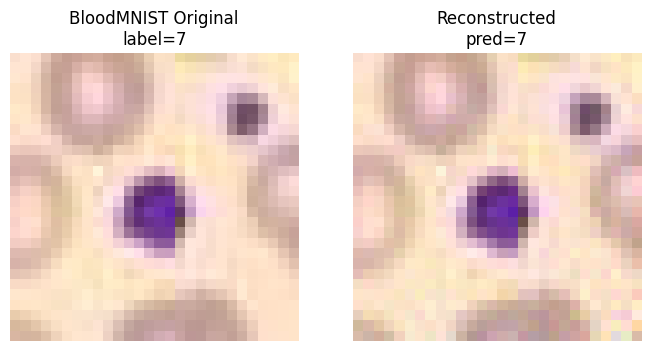

(      dataset  round  batch_size activation    seed  secret_index  true_label  \
 0       MNIST      1           1    Sigmoid  851852             0           5   
 1       MNIST      1           1    Sigmoid  178934             1           0   
 2       MNIST      1           1    Sigmoid   26417             2           4   
 3  BloodMNIST      1           1    Sigmoid  851852             0           7   
 4  BloodMNIST      1           1    Sigmoid  178934             1           3   
 5  BloodMNIST      1           1    Sigmoid   26417             2           6   
 
    pred_label  label_ok           mse      ssim  
 0           5         1  4.880487e-07  0.999918  
 1           0         1  2.381830e-06  0.999874  
 2           4         1  3.569982e-06  0.999742  
 3           7         1  2.488095e-04  0.987879  
 4           3         1  1.508636e-04  0.996103  
 5           6         1  2.270471e-04  0.994376  ,
       dataset  runs  mse_median  ssim_median
 0  BloodMNIST     3

In [22]:
#EXPERIMENT: DATA COMPLEXITY IMPACT (MNIST vs BloodMNIST) 
import copy
import importlib.util
import subprocess
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from skimage.metrics import structural_similarity as ssim
from torch.utils.data import DataLoader, TensorDataset
from torchvision import datasets, transforms

from aijack.attack.inversion import GradientInversionAttackServerManager
from aijack.collaborative.fedavg import FedAVGAPI, FedAVGClient, FedAVGServer


if importlib.util.find_spec("medmnist") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "medmnist"])

import medmnist
from medmnist import INFO


blood_info = INFO["bloodmnist"]
BloodMNIST = getattr(medmnist, blood_info["python_class"])


target_round = 1
batch_size = 1
activation_cls = nn.Sigmoid
secret_indices_complexity = [0, 1, 2]
client_lr_complexity = 0.1
criterion_complexity = nn.CrossEntropyLoss()

rng = np.random.default_rng(2026)
seed_map = {idx: int(rng.integers(0, 1_000_000)) for idx in secret_indices_complexity}


class LeNetDynamic(nn.Module):
    def __init__(self, in_channels: int, out_classes: int, activation=nn.Sigmoid):
        super().__init__()
        self.body = nn.Sequential(
            nn.Conv2d(in_channels, 12, kernel_size=5, padding=2, stride=2),
            activation(),
            nn.Conv2d(12, 12, kernel_size=5, padding=2, stride=2),
            activation(),
        )
        self.fc = nn.Linear(12 * 7 * 7, out_classes)

    def forward(self, x):
        out = self.body(x)
        out = out.view(out.size(0), -1)
        return self.fc(out)


def _extract_int_label(label_obj):
    if torch.is_tensor(label_obj):
        return int(label_obj.item())
    if isinstance(label_obj, np.ndarray):
        return int(label_obj.squeeze())
    return int(label_obj)


def _make_attacking_server_class(input_channels: int):
    manager_local = GradientInversionAttackServerManager(
        (input_channels, 28, 28),
        device=device,
        num_iteration=100,
        lr=1.0,
        log_interval=20,
        optimizer_class=torch.optim.LBFGS,
        distancename="l2",
    )
    return manager_local.attach(FedAVGServer)


def run_complexity_attack(dataset_name, dataset_obj, in_channels, out_classes, secret_index, seed):
    torch.manual_seed(seed)
    np.random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    secret_x_cpu, secret_y_raw = dataset_obj[secret_index]
    true_label = _extract_int_label(secret_y_raw)

    secret_x_cpu = secret_x_cpu.unsqueeze(0)
    secret_y_cpu = torch.tensor([true_label], dtype=torch.long)

    model = LeNetDynamic(in_channels=in_channels, out_classes=out_classes, activation=activation_cls).to(device)
    client_tmp = FedAVGClient(copy.deepcopy(model), user_id=0, lr=client_lr_complexity, device=device)

    AttackingServerLocal = _make_attacking_server_class(in_channels)
    server_tmp = AttackingServerLocal([client_tmp], copy.deepcopy(model), device=device)

    local_dataloaders_tmp = [
        DataLoader(TensorDataset(secret_x_cpu, secret_y_cpu), batch_size=batch_size, shuffle=False)
    ]
    local_optimizers_tmp = [optim.SGD(client_tmp.parameters(), lr=client_lr_complexity)]

    api_tmp = FedAVGAPI(
        server_tmp,
        [client_tmp],
        criterion_complexity,
        local_optimizers_tmp,
        local_dataloaders_tmp,
        num_communication=target_round,
        local_epoch=1,
        use_gradients=True,
        device=device,
    )
    api_tmp.run()

    recon_x, recon_y = server_tmp.attack_results[-1][0]

    if recon_y.ndim == 0:
        pred_label = int(recon_y.item())
    elif recon_y.ndim == 1:
        pred_label = int(torch.argmax(recon_y).item())
    else:
        pred_label = int(torch.argmax(recon_y[0]).item())

    secret_arr = secret_x_cpu[0].detach().cpu().numpy()
    recon_arr = recon_x[0].detach().cpu().numpy()

    mse_score = float(np.mean((recon_arr - secret_arr) ** 2))

    if dataset_name == "BloodMNIST":
        ssim_score = float(ssim(secret_arr, recon_arr, data_range=1.0, channel_axis=0))
    else:
        ssim_score = float(ssim(secret_arr[0], recon_arr[0], data_range=1.0))

    row = {
        "dataset": dataset_name,
        "round": target_round,
        "batch_size": batch_size,
        "activation": activation_cls.__name__,
        "seed": seed,
        "secret_index": secret_index,
        "true_label": true_label,
        "pred_label": pred_label,
        "label_ok": int(pred_label == true_label),
        "mse": mse_score,
        "ssim": ssim_score,
    }

    artifacts = {
        "secret": secret_arr,
        "recon": recon_arr,
        "true_label": true_label,
        "pred_label": pred_label,
    }
    return row, artifacts



mnist_dataset = datasets.MNIST(root="./data", train=True, download=True, transform=transforms.ToTensor())
blood_dataset = BloodMNIST(split="train", transform=transforms.ToTensor(), download=True, as_rgb=True)

dataset_specs = [
    {"name": "MNIST", "dataset": mnist_dataset, "in_channels": 1, "out_classes": 10},
    {"name": "BloodMNIST", "dataset": blood_dataset, "in_channels": 3, "out_classes": 8},
]

rows_complexity = []
blood_example = None

for spec in dataset_specs:
    for idx in secret_indices_complexity:
        seed = seed_map[idx]
        print(f"Running dataset={spec['name']}, secret_index={idx}, seed={seed} ...")
        row, artifacts = run_complexity_attack(
            dataset_name=spec["name"],
            dataset_obj=spec["dataset"],
            in_channels=spec["in_channels"],
            out_classes=spec["out_classes"],
            secret_index=idx,
            seed=seed,
        )
        rows_complexity.append(row)

        if spec["name"] == "BloodMNIST" and blood_example is None:
            blood_example = artifacts


df_complexity = pd.DataFrame(rows_complexity)
csv_path_complexity = "results_complexity_comparison.csv"
df_complexity.to_csv(csv_path_complexity, index=False)

summary_complexity = (
    df_complexity.groupby("dataset", as_index=False)
    .agg(
        runs=("ssim", "size"),
        mse_median=("mse", "median"),
        ssim_median=("ssim", "median"),
    )
    .sort_values("dataset")
    .reset_index(drop=True)
)

print("\nSaved raw results:", csv_path_complexity)
print("\nSummary table: Median SSIM by Dataset")
print(summary_complexity[["dataset", "ssim_median"]].to_string(index=False))


if blood_example is not None:
    orig_rgb = np.transpose(blood_example["secret"], (1, 2, 0))
    recon_rgb = np.transpose(blood_example["recon"], (1, 2, 0))

    fig, axes = plt.subplots(1, 2, figsize=(7, 3.5))
    axes[0].imshow(np.clip(orig_rgb, 0.0, 1.0))
    axes[0].set_title(f"BloodMNIST Original\nlabel={blood_example['true_label']}")
    axes[0].axis("off")

    axes[1].imshow(np.clip(recon_rgb, 0.0, 1.0))
    axes[1].set_title(f"Reconstructed\npred={blood_example['pred_label']}")
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()


df_complexity, summary_complexity

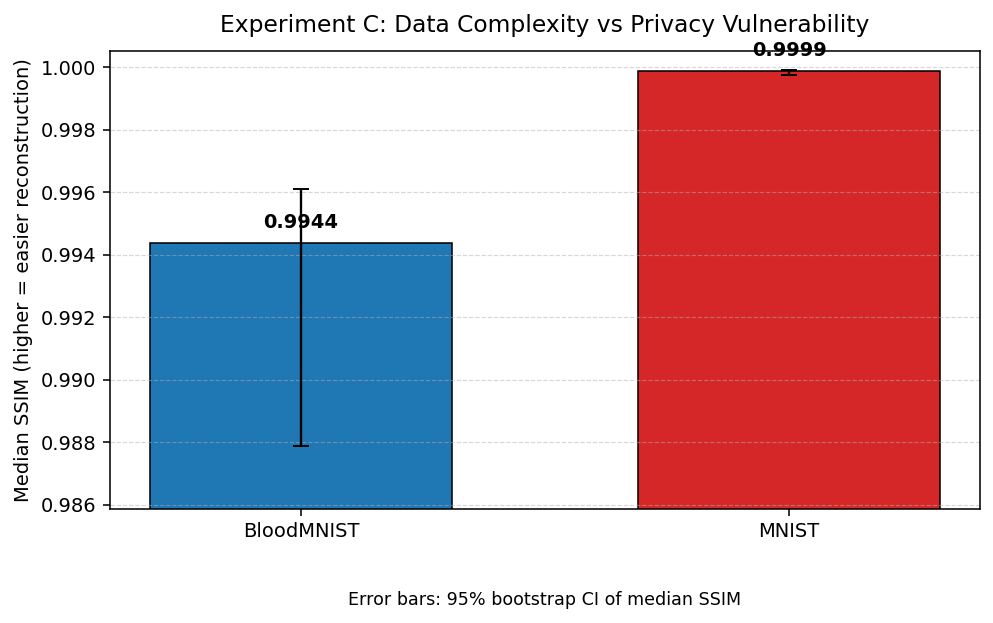

,dataset,ssim_median,ci_low,ci_high,n
0,BloodMNIST,0.994376,0.987879,0.996103,3
1,MNIST,0.999874,0.999742,0.999918,3


In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

csv_path_complexity = "results_complexity_comparison.csv"
df_plot = pd.read_csv(csv_path_complexity)


def bootstrap_ci_median(values, n_boot=2000, alpha=0.05, seed=42):
    rng = np.random.default_rng(seed)
    arr = np.asarray(values, dtype=float)
    boot_stats = []
    for _ in range(n_boot):
        sample = rng.choice(arr, size=len(arr), replace=True)
        boot_stats.append(np.median(sample))
    low = float(np.quantile(boot_stats, alpha / 2))
    high = float(np.quantile(boot_stats, 1 - alpha / 2))
    return low, high


plot_rows = []
for dataset_name, grp in df_plot.groupby("dataset"):
    med = float(np.median(grp["ssim"].values))
    ci_low, ci_high = bootstrap_ci_median(grp["ssim"].values, n_boot=2000, alpha=0.05, seed=2026)
    plot_rows.append(
        {
            "dataset": dataset_name,
            "ssim_median": med,
            "ci_low": ci_low,
            "ci_high": ci_high,
            "n": int(len(grp)),
        }
    )

plot_df = pd.DataFrame(plot_rows).sort_values("dataset").reset_index(drop=True)

x = np.arange(len(plot_df))
y = plot_df["ssim_median"].values
yerr_lower = y - plot_df["ci_low"].values
yerr_upper = plot_df["ci_high"].values - y

fig, ax = plt.subplots(figsize=(7.2, 4.6), dpi=140)
colors = ["#1f77b4", "#d62728"]
bars = ax.bar(x, y, color=colors[: len(x)], width=0.62, edgecolor="black", linewidth=0.8)

ax.errorbar(
    x,
    y,
    yerr=[yerr_lower, yerr_upper],
    fmt="none",
    ecolor="black",
    elinewidth=1.2,
    capsize=4,
)

for i, b in enumerate(bars):
    ax.text(
        b.get_x() + b.get_width() / 2,
        b.get_height() + 0.00035,
        f"{y[i]:.4f}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
    )

ax.set_title("Experiment C: Data Complexity vs Privacy Vulnerability", fontsize=12, pad=10)
ax.set_ylabel("Median SSIM (higher = easier reconstruction)", fontsize=10)
ax.set_xticks(x)
ax.set_xticklabels(plot_df["dataset"].tolist(), fontsize=10)
ax.set_ylim(max(0.98, float(np.min(plot_df["ci_low"]) - 0.002)), 1.0005)
ax.grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.5)

caption = "Error bars: 95% bootstrap CI of median SSIM"
ax.text(0.5, -0.18, caption, ha="center", va="top", transform=ax.transAxes, fontsize=9)

plt.tight_layout()
plt.show()

plot_df

What does it change if we use differential privacy? ("artificial" data protection)

DPManager/GaussianDPClientManager not available in this AIJack version.
Using compatible fallback: DPSGDManager + DPSGDClientManager
Import error: cannot import name 'DPManager' from 'aijack.defense.dp' (/Users/flaviafuscaldi/Desktop/fl_thesis/.venv/lib/python3.10/site-packages/aijack/defense/dp/__init__.py)
Running DP attack with sigma=0, secret_index=7, seed=0 ...
communication 0, epoch 0: client-1 2.212738513946533
iter=20: 145.2177734375, (best_iter=2: 5.571815013885498)
iter=40: 145.2177734375, (best_iter=2: 5.571815013885498)
iter=53: loss did not improve in the last 50 rounds.
Running DP attack with sigma=0, secret_index=13, seed=0 ...
communication 0, epoch 0: client-1 2.390902042388916
iter=20: 121.15287017822266, (best_iter=1: 67.19215393066406)
iter=40: 121.15287017822266, (best_iter=1: 67.19215393066406)
iter=52: loss did not improve in the last 50 rounds.
Running DP attack with sigma=0, secret_index=25, seed=0 ...
communication 0, epoch 0: client-1 2.210422992706299
iter=2

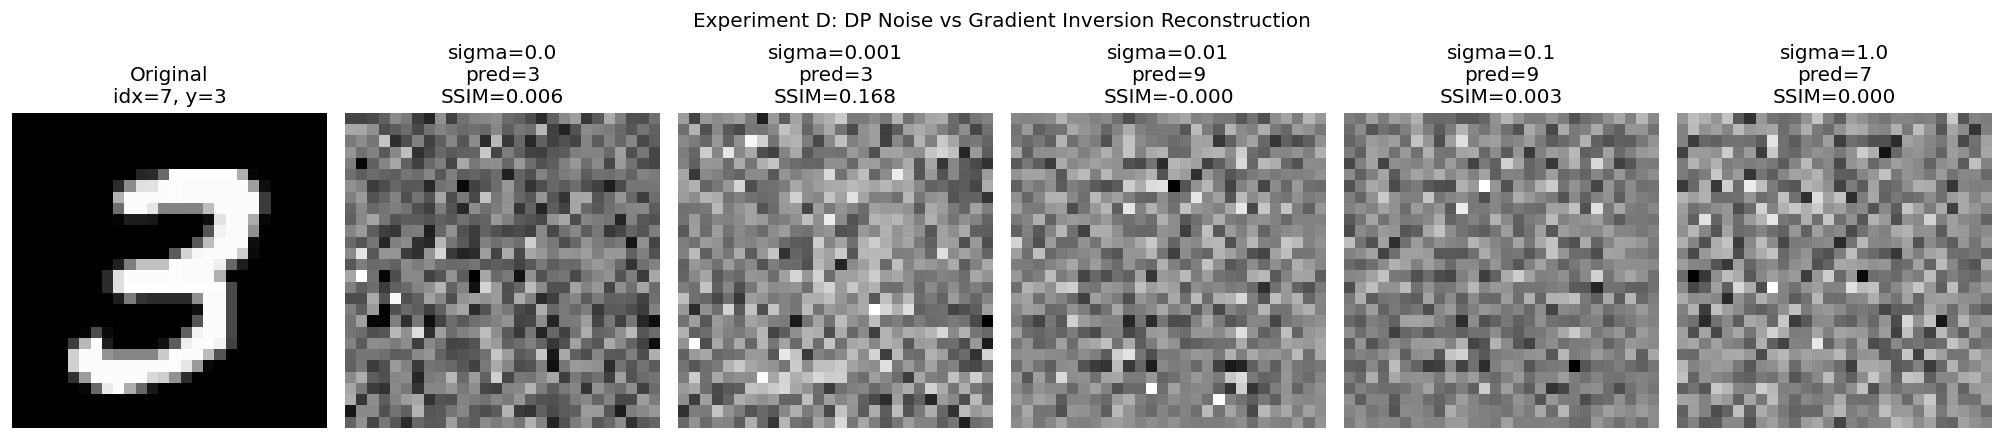

(    sigma  round  batch_size activation  seed  secret_index  true_label  \
 0   0.000      1           1    Sigmoid     0             7           3   
 1   0.000      1           1    Sigmoid     0            13           6   
 2   0.000      1           1    Sigmoid     0            25           2   
 3   0.001      1           1    Sigmoid     0             7           3   
 4   0.001      1           1    Sigmoid     0            13           6   
 5   0.001      1           1    Sigmoid     0            25           2   
 6   0.010      1           1    Sigmoid     0             7           3   
 7   0.010      1           1    Sigmoid     0            13           6   
 8   0.010      1           1    Sigmoid     0            25           2   
 9   0.100      1           1    Sigmoid     0             7           3   
 10  0.100      1           1    Sigmoid     0            13           6   
 11  0.100      1           1    Sigmoid     0            25           2   
 12  1.000  

In [24]:
#EXPERIMENT: DIFFERENTIAL PRIVACY (DP)
import copy
import inspect
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.optim as optim
from skimage.metrics import structural_similarity as ssim
from torch.utils.data import DataLoader, TensorDataset


target_round_dp = 1
batch_size_dp = 1
activation_name_dp = "Sigmoid"
secret_indices_dp = [7, 13, 25]
seeds_dp = [0]  # 1 seed each
sigma_values = [0, 0.001, 0.01, 0.1, 1.0]
client_lr_dp = 0.1
l2_norm_clip_dp = 1.0
iterations_dp = 1

AttackingServer = manager.attach(FedAVGServer)

use_requested_dp_stack = False
requested_dp_error = None
try:
    from aijack.defense.dp import DPManager, GaussianDPClientManager  # type: ignore

    use_requested_dp_stack = True
except Exception as ex:
    requested_dp_error = str(ex)
    from aijack.defense.dp import DPSGDManager, GeneralMomentAccountant
    from aijack.defense.dp.manager import DPSGDClientManager


if use_requested_dp_stack:
    print("Using requested AIJack DP stack: DPManager + GaussianDPClientManager")
else:
    print("DPManager/GaussianDPClientManager not available in this AIJack version.")
    print("Using compatible fallback: DPSGDManager + DPSGDClientManager")
    print("Import error:", requested_dp_error)


def _make_dp_wrapped_client_and_optimizer(base_model_tmp, sigma, secret_dataset):
    """
    Return (client_instance, optimizer_instance) for DP training.
    Uses requested AIJack classes when available, otherwise uses DPSGD fallback.
    """
    if use_requested_dp_stack:
        manager_sig = inspect.signature(DPManager)
        kwargs = {}
        if "dataset" in manager_sig.parameters:
            kwargs["dataset"] = secret_dataset
        if "optimizer_cls" in manager_sig.parameters:
            kwargs["optimizer_cls"] = optim.SGD
        if "l2_norm_clip" in manager_sig.parameters:
            kwargs["l2_norm_clip"] = l2_norm_clip_dp
        if "lot_size" in manager_sig.parameters:
            kwargs["lot_size"] = batch_size_dp
        if "batch_size" in manager_sig.parameters:
            kwargs["batch_size"] = batch_size_dp
        if "iterations" in manager_sig.parameters:
            kwargs["iterations"] = iterations_dp

        dp_manager = DPManager(**kwargs)

        gsig = inspect.signature(GaussianDPClientManager)
        gkwargs = {}
        if "privacy_manager" in gsig.parameters:
            gkwargs["privacy_manager"] = dp_manager
        if "sigma" in gsig.parameters:
            gkwargs["sigma"] = sigma
        elif "noise_multiplier" in gsig.parameters:
            gkwargs["noise_multiplier"] = sigma

        wrapped = GaussianDPClientManager(**gkwargs).attach(FedAVGClient)
        if isinstance(wrapped, tuple):
            DPFedAVGClient, DPOptimizer = wrapped
        else:
            raise RuntimeError("Unexpected return type from GaussianDPClientManager.attach")

        client_tmp = DPFedAVGClient(copy.deepcopy(base_model_tmp), user_id=0, lr=client_lr_dp, device=device)
        optimizer_tmp = DPOptimizer(client_tmp.parameters(), lr=client_lr_dp)
        return client_tmp, optimizer_tmp

    accountant = GeneralMomentAccountant(noise_type="Gaussian", backend="python")
    dp_manager = DPSGDManager(
        accountant=accountant,
        optimizer_cls=optim.SGD,
        l2_norm_clip=l2_norm_clip_dp,
        dataset=secret_dataset,
        lot_size=batch_size_dp,
        batch_size=batch_size_dp,
        iterations=iterations_dp,
    )
    DPFedAVGClient, DPOptimizer = DPSGDClientManager(dp_manager, sigma=sigma).attach(FedAVGClient)

    client_tmp = DPFedAVGClient(copy.deepcopy(base_model_tmp), user_id=0, lr=client_lr_dp, device=device)
    optimizer_tmp = DPOptimizer(client_tmp.parameters(), lr=client_lr_dp)
    return client_tmp, optimizer_tmp


def run_dp_attack_for_sigma(sigma, secret_index, seed):
    torch.manual_seed(seed)
    np.random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    secret_x_cpu, secret_y_raw = dataset[secret_index]
    secret_x_cpu = secret_x_cpu.unsqueeze(0)
    secret_y_cpu = torch.tensor([int(secret_y_raw)], dtype=torch.long)

    secret_dataset = TensorDataset(secret_x_cpu, secret_y_cpu)

    base_model_tmp = LeNet().to(device)
    client_tmp, optimizer_tmp = _make_dp_wrapped_client_and_optimizer(
        base_model_tmp=base_model_tmp,
        sigma=sigma,
        secret_dataset=secret_dataset,
    )

    server_tmp = AttackingServer([client_tmp], copy.deepcopy(base_model_tmp), device=device)
    local_dataloaders_tmp = [DataLoader(secret_dataset, batch_size=batch_size_dp, shuffle=False)]

    api_tmp = FedAVGAPI(
        server_tmp,
        [client_tmp],
        criterion,
        [optimizer_tmp],
        local_dataloaders_tmp,
        num_communication=target_round_dp,
        local_epoch=1,
        use_gradients=True,
        device=device,
    )
    api_tmp.run()

    recon_x, recon_y = server_tmp.attack_results[-1][0]

    if recon_y.ndim == 0:
        pred_label = int(recon_y.item())
    elif recon_y.ndim == 1:
        pred_label = int(torch.argmax(recon_y).item())
    else:
        pred_label = int(torch.argmax(recon_y[0]).item())

    recon_img = recon_x[0][0].detach().cpu().numpy()
    secret_img = secret_x_cpu[0][0].detach().cpu().numpy()

    mse_score = float(np.mean((recon_img - secret_img) ** 2))
    ssim_score = float(ssim(secret_img, recon_img, data_range=1.0))

    client_tmp.eval()
    with torch.no_grad():
        logits = client_tmp(secret_x_cpu.to(device))
        utility_loss = float(criterion(logits, secret_y_cpu.to(device)).item())
        utility_acc = float((torch.argmax(logits, dim=1) == secret_y_cpu.to(device)).float().mean().item())

    row = {
        "sigma": float(sigma),
        "round": target_round_dp,
        "batch_size": batch_size_dp,
        "activation": activation_name_dp,
        "seed": int(seed),
        "secret_index": int(secret_index),
        "true_label": int(secret_y_cpu.item()),
        "pred_label": pred_label,
        "label_ok": int(pred_label == int(secret_y_cpu.item())),
        "mse": mse_score,
        "ssim": ssim_score,
        "utility_loss": utility_loss,
        "utility_acc": utility_acc,
    }

    artifacts = {
        "sigma": float(sigma),
        "seed": int(seed),
        "secret_index": int(secret_index),
        "secret_img": secret_img,
        "recon_img": recon_img,
        "true_label": int(secret_y_cpu.item()),
        "pred_label": pred_label,
        "ssim": ssim_score,
        "mse": mse_score,
    }

    return row, artifacts



rows_dp = []
artifacts_dp = []
for sigma in sigma_values:
    for idx in secret_indices_dp:
        for seed in seeds_dp:
            print(f"Running DP attack with sigma={sigma}, secret_index={idx}, seed={seed} ...")
            row, art = run_dp_attack_for_sigma(sigma=sigma, secret_index=idx, seed=seed)
            rows_dp.append(row)
            artifacts_dp.append(art)


df_dp = pd.DataFrame(rows_dp)
csv_path_dp = "results_dp_comparison.csv"
df_dp.to_csv(csv_path_dp, index=False)


summary_dp = (
    df_dp.groupby("sigma", as_index=False)
    .agg(
        runs=("ssim", "size"),
        mse_median=("mse", "median"),
        ssim_median=("ssim", "median"),
        utility_loss_median=("utility_loss", "median"),
        utility_acc_mean=("utility_acc", "mean"),
        label_acc_mean=("label_ok", "mean"),
    )
    .sort_values("sigma")
    .reset_index(drop=True)
)
summary_dp["utility_acc_mean"] = 100.0 * summary_dp["utility_acc_mean"]
summary_dp["label_acc_mean"] = 100.0 * summary_dp["label_acc_mean"]

baseline_row = summary_dp[summary_dp["sigma"] == 0.0]
if len(baseline_row) > 0:
    base_loss = float(baseline_row.iloc[0]["utility_loss_median"])
    base_acc = float(baseline_row.iloc[0]["utility_acc_mean"])
    summary_dp["delta_utility_loss_vs_sigma0"] = summary_dp["utility_loss_median"] - base_loss
    summary_dp["delta_utility_acc_vs_sigma0"] = summary_dp["utility_acc_mean"] - base_acc

print("\nSaved raw results:", csv_path_dp)
print("\nSummary table: Median SSIM vs Noise Level")
print(summary_dp[["sigma", "ssim_median"]].to_string(index=False))

print("\nUtility impact summary (client local training):")
utility_cols = [
    "sigma",
    "utility_loss_median",
    "utility_acc_mean",
]
if "delta_utility_loss_vs_sigma0" in summary_dp.columns:
    utility_cols.append("delta_utility_loss_vs_sigma0")
if "delta_utility_acc_vs_sigma0" in summary_dp.columns:
    utility_cols.append("delta_utility_acc_vs_sigma0")
print(summary_dp[utility_cols].to_string(index=False))


viz_secret_index_dp = secret_indices_dp[0]
viz_seed_dp = seeds_dp[0]
viz_candidates = [
    x
    for x in artifacts_dp
    if x["secret_index"] == viz_secret_index_dp and x["seed"] == viz_seed_dp
]
viz_candidates = sorted(viz_candidates, key=lambda x: x["sigma"])

n_cols = len(viz_candidates) + 1
fig, axes = plt.subplots(1, n_cols, figsize=(2.8 * n_cols, 3.6), dpi=120)

axes[0].imshow(viz_candidates[0]["secret_img"], cmap="gray")
axes[0].set_title(f"Original\nidx={viz_secret_index_dp}, y={viz_candidates[0]['true_label']}")
axes[0].axis("off")

for i, item in enumerate(viz_candidates, start=1):
    axes[i].imshow(item["recon_img"], cmap="gray")
    axes[i].set_title(
        f"sigma={item['sigma']}\n"
        f"pred={item['pred_label']}\n"
        f"SSIM={item['ssim']:.3f}"
    )
    axes[i].axis("off")

plt.suptitle("Experiment D: DP Noise vs Gradient Inversion Reconstruction", y=1.04)
plt.tight_layout()
plt.show()


df_dp, summary_dp

As hypothesized, we observe that as the DP noise level (sigma) increases, the median SSIM of the reconstructed image decreases, indicating that the attack's ability to accurately reconstruct the secret image is diminished. At sigma=0 (no noise), we have the highest SSIM, while at higher sigma values, the SSIM drops significantly.

Mapping the breakeven point: 4 sigmas x 4 batch sizes...
Testing sigma=0.0, batch=1... communication 0, epoch 0: client-1 2.4670324325561523
iter=20: 7.536054181400687e-05, (best_iter=7: 7.536054181400687e-05)
iter=40: 7.536054181400687e-05, (best_iter=7: 7.536054181400687e-05)
iter=58: loss did not improve in the last 50 rounds.
SSIM: 0.055
Testing sigma=0.0, batch=4... communication 0, epoch 0: client-1 0.5052351355552673
iter=20: 0.00010834087152034044, (best_iter=7: 0.00010834087152034044)
iter=40: 0.00010834087152034044, (best_iter=7: 0.00010834087152034044)
iter=58: loss did not improve in the last 50 rounds.
SSIM: 0.004
Testing sigma=0.0, batch=8... communication 0, epoch 0: client-1 0.24697482585906982
iter=20: 0.00014076483785174787, (best_iter=7: 0.00014076483785174787)
iter=40: 0.00014076483785174787, (best_iter=7: 0.00014076483785174787)
iter=58: loss did not improve in the last 50 rounds.
SSIM: -0.001
Testing sigma=0.0, batch=16... communication 0, epoch 0: client-1 0.1238

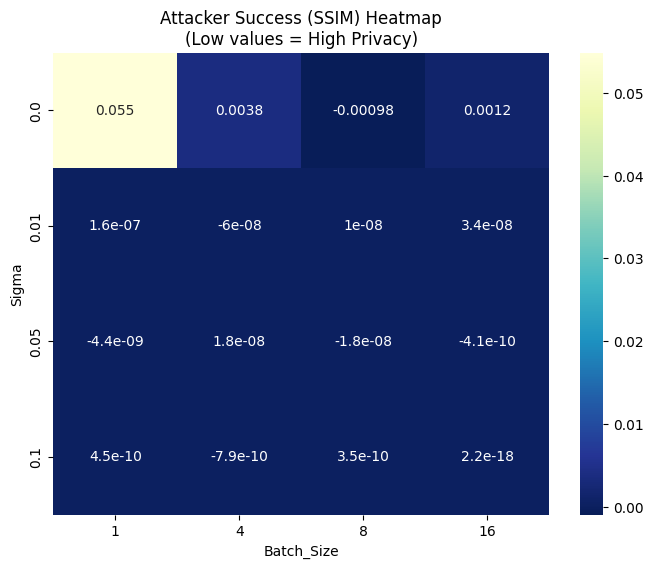

,Sigma,Batch_Size,SSIM
0,0.00,1,5.488566e-02
1,0.00,4,3.792785e-03
2,0.00,8,-9.750400e-04
3,0.00,16,1.215859e-03
4,0.01,1,1.599176e-07
5,0.01,4,-5.954552e-08
6,0.01,8,1.047239e-08
7,0.01,16,3.442180e-08
8,0.05,1,-4.447274e-09
9,0.05,4,1.753121e-08


In [ ]:
import copy

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from skimage.metrics import structural_similarity as ssim
from torch.utils.data import DataLoader, TensorDataset
from torchvision import transforms

from aijack.attack.inversion import GradientInversionAttackServerManager
from aijack.collaborative.fedavg import FedAVGAPI, FedAVGClient, FedAVGServer
from aijack.defense.dp import DPSGDManager, GeneralMomentAccountant
from aijack.defense.dp.manager import DPSGDClientManager


sigmas = [0.0, 0.01, 0.05, 0.1]  
batch_sizes = [1, 4, 8, 16]       
results_grid = []

print(f"Mapping the breakeven point: {len(sigmas)} sigmas x {len(batch_sizes)} batch sizes...")


data_flag = "bloodmnist"
info = INFO[data_flag]
DataClass = getattr(medmnist, info["python_class"])
transform = transforms.Compose([transforms.ToTensor()])
train_dataset = DataClass(split="train", transform=transform, download=True, as_rgb=True)
num_classes_med = int(info.get("n_classes", len(info.get("label", {}))))


class LeNetMed(nn.Module):
    def __init__(self, in_channels=3, out_classes=8):
        super().__init__()
        self.body = nn.Sequential(
            nn.Conv2d(in_channels, 12, kernel_size=5, padding=2, stride=2),
            nn.Sigmoid(),
            nn.Conv2d(12, 12, kernel_size=5, padding=2, stride=2),
            nn.Sigmoid(),
        )
        self.fc = nn.Linear(12 * 7 * 7, out_classes)

    def forward(self, x):
        out = self.body(x)
        out = out.view(out.size(0), -1)
        return self.fc(out)


for s_val in sigmas:
    for b_val in batch_sizes:
        print(f"Testing sigma={s_val}, batch={b_val}...", end=" ")

        
        indices = list(range(b_val))
        x_batch_cpu = torch.stack([train_dataset[i][0] for i in indices])

        labels = []
        for i in indices:
            raw_y = train_dataset[i][1]
            if torch.is_tensor(raw_y):
                labels.append(int(raw_y.squeeze().item()))
            else:
                labels.append(int(np.asarray(raw_y).squeeze()))
        y_batch_cpu = torch.tensor(labels, dtype=torch.long).view(-1)

        batch_dataset = TensorDataset(x_batch_cpu, y_batch_cpu)

        
        base_model = LeNetMed(in_channels=3, out_classes=num_classes_med).to(device)

        accountant = GeneralMomentAccountant(noise_type="Gaussian", backend="python")
        dp_manager = DPSGDManager(
            accountant=accountant,
            optimizer_cls=optim.SGD,
            l2_norm_clip=1.0,
            dataset=batch_dataset,
            lot_size=b_val,
            batch_size=b_val,
            iterations=1,
        )
        DPFedAVGClient, DPOptimizer = DPSGDClientManager(dp_manager, sigma=s_val).attach(FedAVGClient)

        client = DPFedAVGClient(copy.deepcopy(base_model), user_id=0, lr=0.1, device=device)
        local_optimizer = DPOptimizer(client.parameters(), lr=0.1)

        
        med_manager = GradientInversionAttackServerManager(
            (3, 28, 28),
            device=device,
            num_iteration=100,
            lr=1.0,
            log_interval=20,
            optimizer_class=torch.optim.LBFGS,
            distancename="l2",
        )
        AttackingServerMed = med_manager.attach(FedAVGServer)
        server = AttackingServerMed([client], copy.deepcopy(base_model), device=device)

        local_loader = DataLoader(batch_dataset, batch_size=b_val, shuffle=False)
        api_tmp = FedAVGAPI(
            server,
            [client],
            nn.CrossEntropyLoss(),
            [local_optimizer],
            [local_loader],
            num_communication=1,
            local_epoch=1,
            use_gradients=True,
            device=device,
        )
        api_tmp.run()

        
        recon_x, _ = server.attack_results[-1][0]
        orig_img = x_batch_cpu[0].detach().cpu().numpy()

        recon_cpu = recon_x.detach().cpu()
        if recon_cpu.ndim == 4 and recon_cpu.shape[0] > 1:
            mse_candidates = [
                float(np.mean((recon_cpu[i].numpy() - orig_img) ** 2))
                for i in range(recon_cpu.shape[0])
            ]
            recon_np = recon_cpu[int(np.argmin(mse_candidates))].numpy()
        else:
            recon_np = recon_cpu[0].numpy()

        current_ssim = float(ssim(orig_img, recon_np, data_range=1.0, channel_axis=0))

        results_grid.append(
            {
                "Sigma": float(s_val),
                "Batch_Size": int(b_val),
                "SSIM": current_ssim,
            }
        )
        print(f"SSIM: {current_ssim:.3f}")


df_grid = pd.DataFrame(results_grid)
df_grid.to_csv("results_privacy_heatmap.csv", index=False)

pivot_ssim = df_grid.pivot(index="Sigma", columns="Batch_Size", values="SSIM")

plt.figure(figsize=(8, 6))
sns.heatmap(pivot_ssim, annot=True, cmap="YlGnBu_r")
plt.title("Attacker Success (SSIM) Heatmap\n(Low values = High Privacy)")
plt.show()

df_grid

NEXT STEPS:

- Find a sort of best equilibrium between DATA PROTECTION and FEDERATED MODEL PERFORMANCES

- Experiment with other datasets (TEXT?)

- Experiment with other kind of attacks to see what it changes 